In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime

In [3]:

df = pd.read_csv("road_accident.csv", encoding='latin1')



In [4]:
# Display first rows and column names
print(df.head())


     BLOTTER NUMBER      DATE ENCODED      PRO         PPO            STATION  \
0  043424-202201-03  01/01/2022 22:05  PRO 4-A  LAGUNA PPO  San Pablo City PS   
1  043424-202201-09  03/01/2022 15:20  PRO 4-A  LAGUNA PPO  San Pablo City PS   
2  043424-202201-22  04/01/2022 21:08  PRO 4-A  LAGUNA PPO  San Pablo City PS   
3  043424-202201-24  04/01/2022 21:18  PRO 4-A  LAGUNA PPO  San Pablo City PS   
4  043424-202201-24  04/01/2022 21:18  PRO 4-A  LAGUNA PPO  San Pablo City PS   

   PCP      REGION PROVINCE            CITY       BARANGAY  ...  Court/Branch  \
0  NaN  CALABARZON   LAGUNA  SAN PABLO CITY    San Ignacio  ...           NaN   
1  NaN  CALABARZON   LAGUNA  SAN PABLO CITY      San Mateo  ...           NaN   
2  NaN  CALABARZON   LAGUNA  SAN PABLO CITY  San Francisco  ...           NaN   
3  NaN  CALABARZON   LAGUNA  SAN PABLO CITY    San Ignacio  ...           NaN   
4  NaN  CALABARZON   LAGUNA  SAN PABLO CITY    San Ignacio  ...           NaN   

    LATITUDE   LONGITUDE V

In [5]:
print(df.columns)

Index(['BLOTTER NUMBER', 'DATE ENCODED', 'PRO', 'PPO', 'STATION', 'PCP',
       'REGION', 'PROVINCE', 'CITY', 'BARANGAY', 'STREET', 'TYPE OF PLACE',
       'DATE REPORTED', 'TIME REPORTED', 'DATE COMMITTED', 'TIME COMMITTED',
       'INCIDENT TYPE', 'STAGES OF FELONY', 'OFFENSE', 'OFFENSE CATEGORY',
       'SECTION', 'CRIME CATEGORY', 'MODUS', 'MRS', 'SUSPECT MOTIVE',
       'SUSPECT SUB-MOTIVE', 'PRIVATE/PUBLIC', 'VICTIMS Name',
       'VICTIMS Status', 'VICTIMS Age', 'VICTIMS Gender', 'VICTIMS Occupation',
       'VICTIMS Relation to Suspect', 'VICTIM IS EGO', 'VICTIM EGO POSITION',
       'VICTIM EGO CLASS', 'VICTIMS Nationality', 'VICTIMS Sector',
       'VICTIMS Ethnic Group', 'VICTIMS Address (Local)', 'SUSPECTS Name',
       'SUSPECTS Status', 'SUSPECTS Age', 'SUSPECTS Gender',
       'SUSPECTS Occupation', 'SUSPECT IS EGO', 'SUSPECT EGO POSITION',
       'SUSPECT EGO CLASS', 'SUSPECTS Nationality', 'SUSPECTS Education',
       'SUSPECTS Drug Used', 'SUSPECTS Alcohol Used',
    

In [6]:
df.rename(columns={
    'DATE ENCODED': 'Date',
    'DATE_REPORTED': 'Date',   # try this if above doesn't work
    'date': 'Date'
}, inplace=True)

In [7]:
# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [8]:
# Drop rows with invalid dates
df = df.dropna(subset=['Date'])

In [9]:
# 2022 only
df_2022 = df[df['Date'].dt.year == 2022].copy()
monthly_data = df_2022.groupby(pd.Grouper(key='Date', freq='ME')).size()

In [10]:
# Ensure 12 months
full_range = pd.date_range('2022-01-01', '2022-12-31', freq='ME')
monthly_data = monthly_data.reindex(full_range, fill_value=0)
monthly_data.index = monthly_data.index.strftime('%Y-%m')

In [11]:
print("2022 Monthly Data:")
print(monthly_data)

2022 Monthly Data:
2022-01    19
2022-02    32
2022-03    57
2022-04    49
2022-05    54
2022-06    29
2022-07    27
2022-08    47
2022-09    25
2022-10    13
2022-11    26
2022-12    13
dtype: int64


In [12]:
# === 70/15/15 Split ===
n = len(monthly_data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = monthly_data.iloc[:train_end]
val = monthly_data.iloc[train_end:val_end]
test = monthly_data.iloc[val_end:]
print(f"\n70/15/15 Split → Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")


70/15/15 Split → Train: 8 | Val: 2 | Test: 2


# DON'T RUN THIS BELOW ⬇

In [ ]:
print("\nTraining ARIMA model with auto_arima (this finds the best p,d,q)...")
model = auto_arima(
    monthly_data,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    m=12,              # monthly seasonality
    seasonal=True,     # SARIMA
    d=1,               # differencing
    D=0,               # seasonal differencing - changed from 1 to 0
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

forecast = model.predict(n_periods=len(test))


Training ARIMA model with auto_arima (this finds the best p,d,q)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=100.441, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=96.441, Time=0.02 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=94.453, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=98.441, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=98.441, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=98.042, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.09 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=100.171, Time=0.09 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 0.981 seconds


In [ ]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   12
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -46.227
Date:                Wed, 10 Dec 2025   AIC                             94.453
Time:                        16:39:16   BIC                             94.851
Sample:                    01-01-2022   HQIC                            94.202
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       261.6364    187.408      1.396      0.163    -105.677     628.950
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):                 0.76
Prob(Q):                              0.48   Pr

In [ ]:
# === METRICS ===
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / (test + 1))) * 100  # +1 to avoid divide by zero

print(f"\n80/20 RESULTS:")
print(f"MAE  : {mae:.2f} accidents")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.1f}%")


80/20 RESULTS:
MAE  : 4.33 accidents
RMSE : 7.51
MAPE : nan%


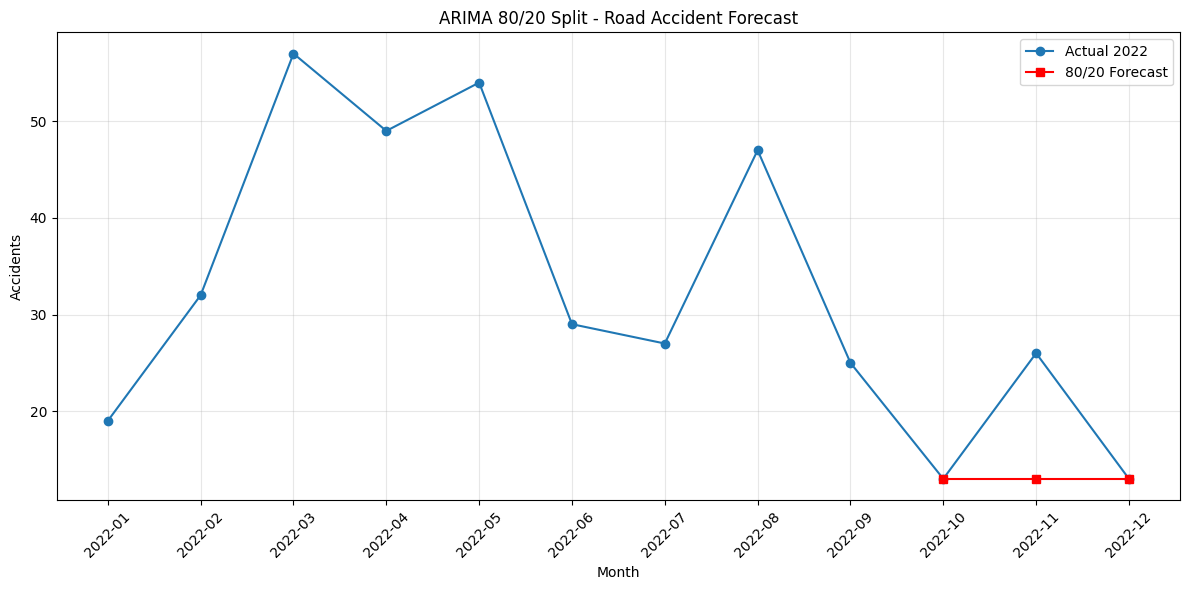

In [ ]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, monthly_data.values, label='Actual 2022', marker='o')
plt.plot(test.index, forecast, label='80/20 Forecast', marker='s', color='red')
plt.title('ARIMA 80/20 Split - Road Accident Forecast')
plt.xlabel('Month'); plt.ylabel('Accidents')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [ ]:
with open('forecast_80_20.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as forecast_80_20.pkl → Ready for Flask!")

Model saved as forecast_80_20.pkl → Ready for Flask!


# UPTO THIS ☝

# TRAINING FOR SARIMA ⬇

In [13]:
print("\nTraining SARIMA model with seasonal differencing (D=1)...")
sarima_model_D1 = auto_arima(
    monthly_data,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    m=12,              # monthly seasonality
    seasonal=True,     # SARIMA
    d=1,               # differencing
    D=0,               # seasonal differencing (changed from 1 to 0)
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(sarima_model_D1.summary())


Training SARIMA model with seasonal differencing (D=1)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=100.441, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=96.441, Time=0.02 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=94.453, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=98.441, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=98.441, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=98.042, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.09 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=100.171, Time=0.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 1.005 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   12
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -46.227
Date:                Sat, 03 Jan 2026   AIC                             94.453
Time:                        15:20:10   BIC                             94.851
Sample:                    01-01-2022   HQIC                            94.202
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       261.6364    187.408      1.396      0.163    -105.677

In [14]:
# Make a forecast using the new SARIMA model
sarima_forecast_D1 = sarima_model_D1.predict(n_periods=len(test))

# Evaluate the new model
mae_sarima_D1 = mean_absolute_error(test, sarima_forecast_D1)
rmse_sarima_D1 = np.sqrt(mean_squared_error(test, sarima_forecast_D1))
mape_sarima_D1 = np.mean(np.abs((test - sarima_forecast_D1) / (test + 1))) * 100

print(f"\nSARIMA (D=1) RESULTS:")
print(f"MAE  : {mae_sarima_D1:.2f} accidents")
print(f"RMSE : {rmse_sarima_D1:.2f}")
print(f"MAPE : {mape_sarima_D1:.1f}%")




SARIMA (D=1) RESULTS:
MAE  : 6.50 accidents
RMSE : 9.19
MAPE : nan%


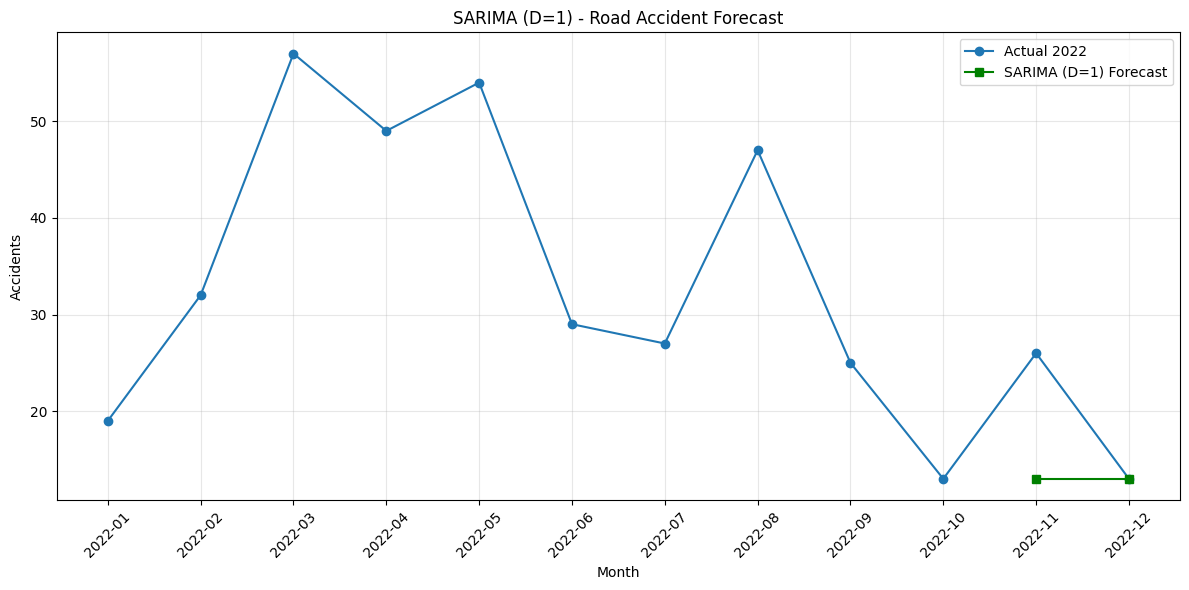

In [15]:
# Plot the new SARIMA forecast
plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, monthly_data.values, label='Actual 2022', marker='o')
plt.plot(test.index, sarima_forecast_D1, label='SARIMA (D=1) Forecast', marker='s', color='green')
plt.title('SARIMA (D=1) - Road Accident Forecast')
plt.xlabel('Month'); plt.ylabel('Accidents')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [16]:
with open('SARIMA_forecast_70_15_15.pkl', 'wb') as f:
    pickle.dump(sarima_model_D1, f)

print("Model saved as SARIMA_forecast_70_15_15.pkl → Ready for Flask!")

Model saved as SARIMA_forecast_70_15_15.pkl → Ready for Flask!
